# GARCH


In [1]:
if (!require("quantmod")) {
  install.packages("quantmod")
}
if (!require("tidyverse")) {
  install.packages("tidyverse")
}
if (!require("xts")) {
  install.packages("xts")
}
if (!require("rugarch")) {
  install.packages("rugarch")
}

library(quantmod)
library(tidyverse)
library(xts)
library(rugarch)

Loading required package: quantmod

Loading required package: xts

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: TTR

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Loading required package: tidyverse

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::first()  masks xts::first()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::last()   masks xts::last()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package

Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d1>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <8e>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d0>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <bd>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d0>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <b8>”
Warning message in axis(1, at = xcoords[axt], labels = lab

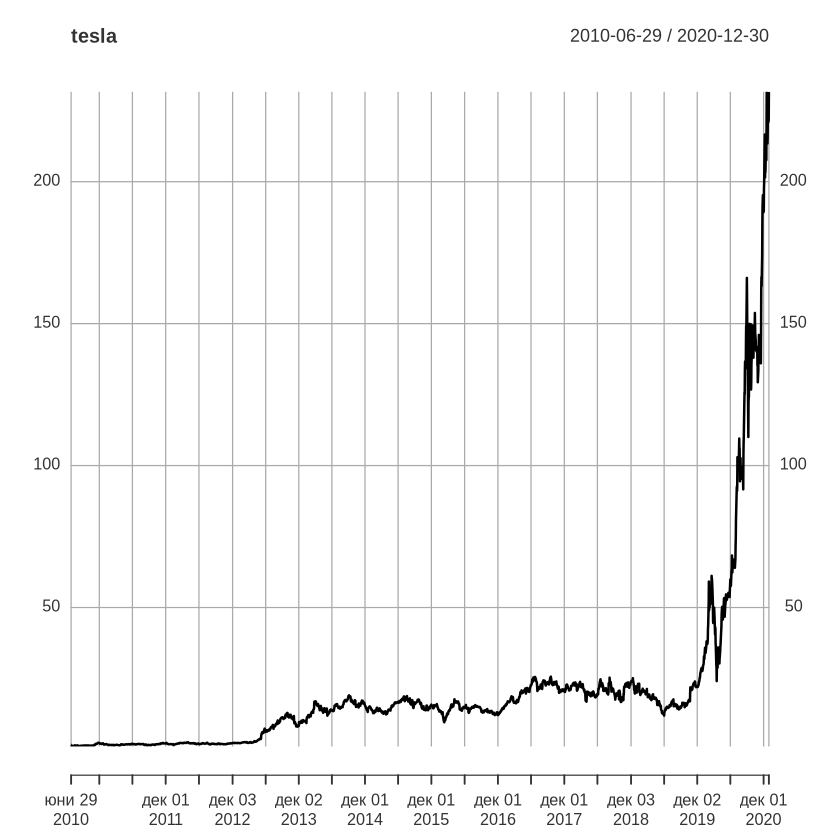

In [2]:

dt <- getSymbols("TSLA", from = "2010-01-01", to = "2020-12-31", auto.assign = FALSE)

## Get the adjusted close price for each trading day
##
tesla <- dt$TSLA.Adjusted
plot(tesla)

Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d1>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <8e>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d0>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <bd>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d0>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <b8>”
Warning message in axis(1, at = xcoords[axt], labels = lab

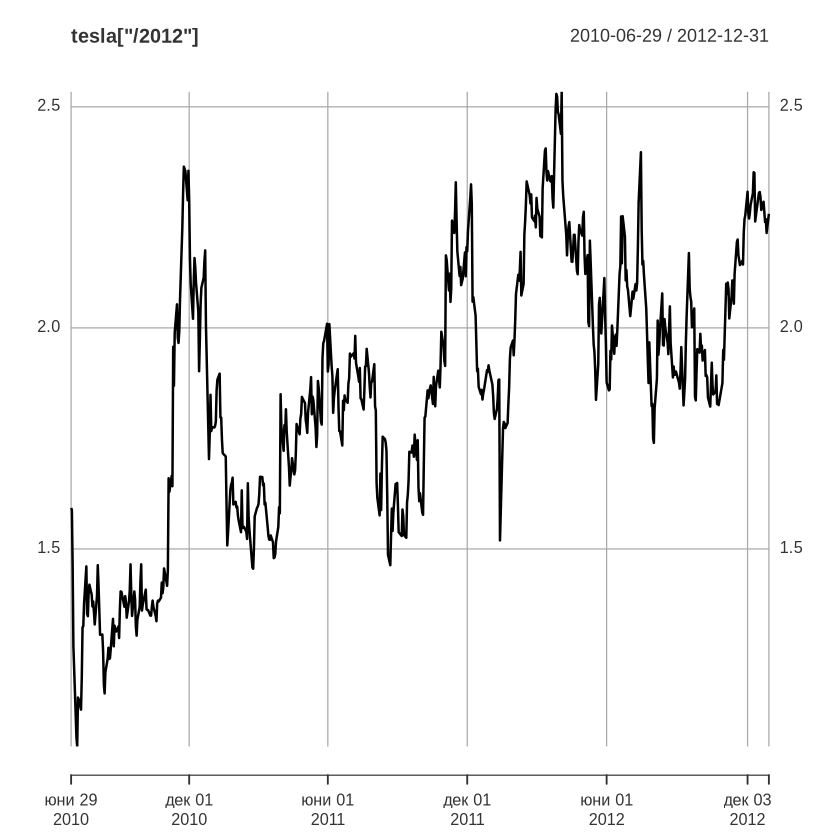

In [3]:
plot(tesla["/2012"])

Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d1>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <8e>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d0>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <bd>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <d0>”
Warning message in axis(1, at = xcoords[axt], labels = labels, las = theme$las, :
“conversion failure on 'юни 29' in 'mbcsToSbcs': dot substituted for <b8>”
Warning message in axis(1, at = xcoords[axt], labels = lab

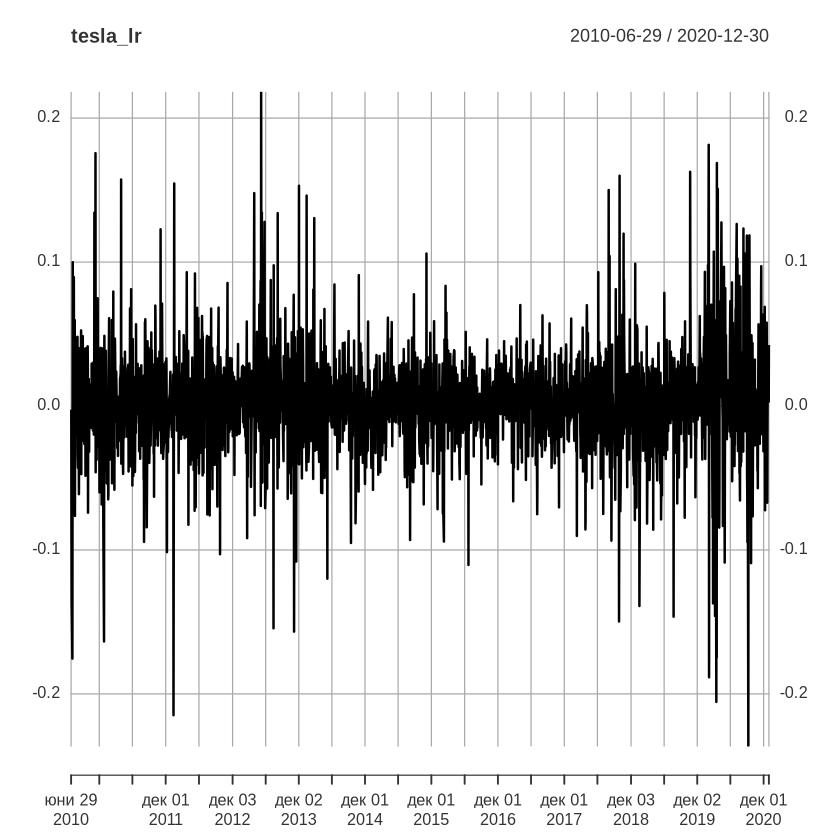

In [5]:
tesla_lr <- diff(log(tesla))
plot(tesla_lr)

In [6]:
fit_AR0 <- arima(tesla_lr, order = c(0, 0, 0))
fit_AR0


Call:
arima(x = tesla_lr, order = c(0, 0, 0))

Coefficients:
      intercept
         0.0019
s.e.     0.0007

sigma^2 estimated as 0.001248:  log likelihood = 5089.41,  aic = -10174.82

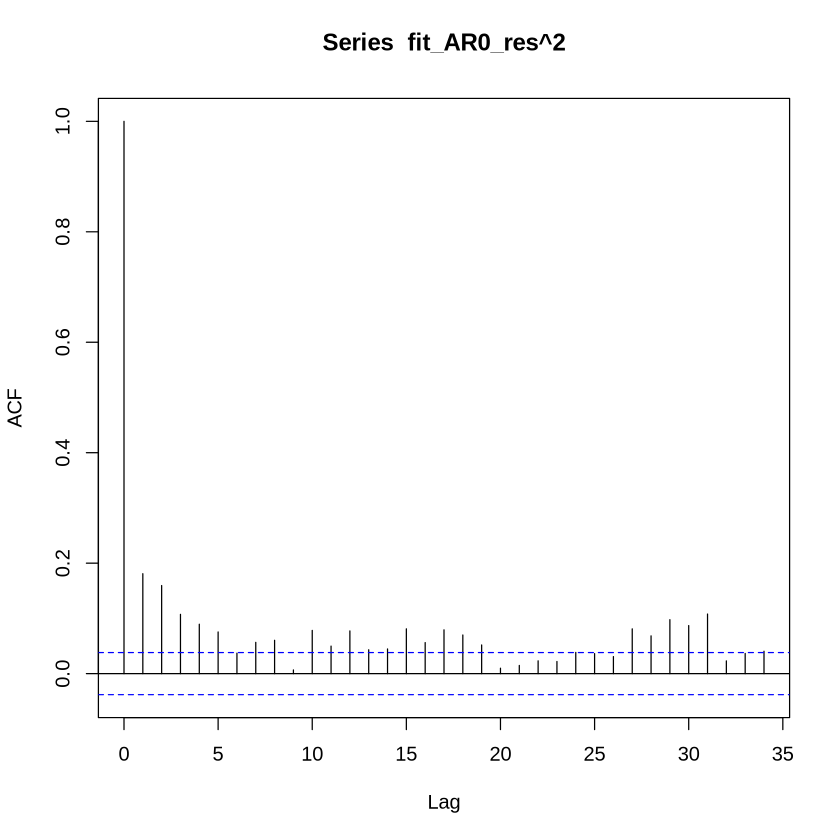

In [ ]:
fit_AR0_res <- residuals(fit_AR0)

acf(fit_AR0_res^2, na.action = na.pass)

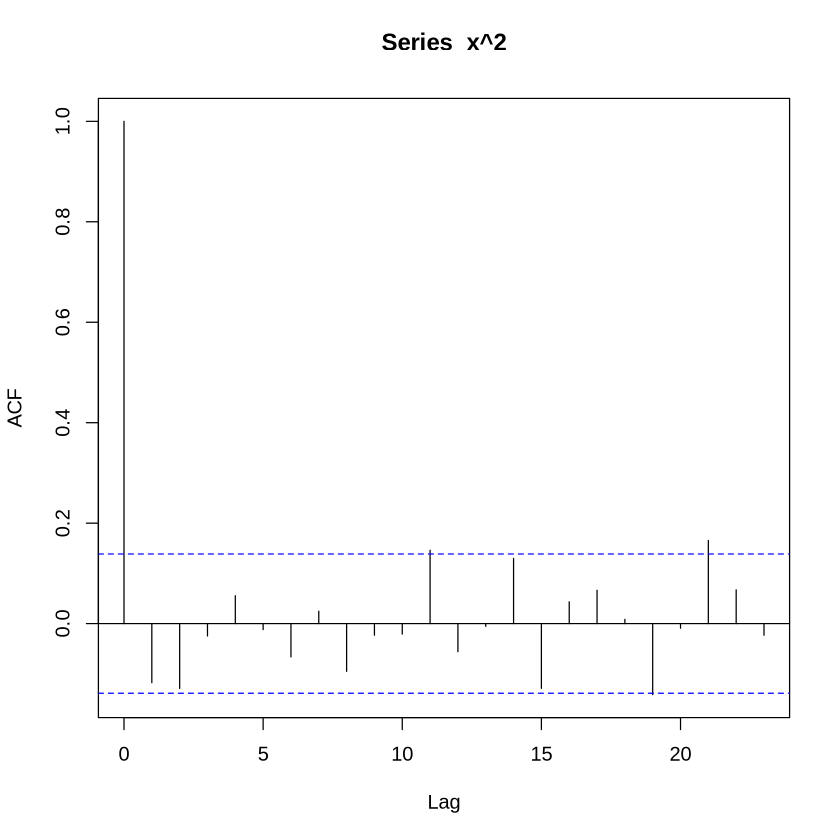

In [8]:
x <- rnorm(200)
acf(x^2)

$$
\begin{align*}
h_{t}^2 & = \alpha_0 + \alpha_1 e^2_{t - 1} + \alpha_2 e^2_{t - 2} + \ldots + \alpha_q e^2_{t - q} \\
h_{t + 1}^2 & = \alpha_0 + \alpha_1 e^2_{t} + \alpha_2 e^2_{t - 1} + \ldots + \alpha_q e^2_{t - q + 1}
\end{align*}
$$

$$
h^2_t = \alpha_0 + \alpha_1 e^2_{1 - 1} + \alpha_2 e^2_{1 - 2} + \ldots + \alpha_q e^2_{t - q} + \beta_1 h^2_{t - 1} + \ldots + \beta_p h^2_{t - p}
$$

## GARCH(1, 1)

The GARCH(1, 1) model is sufficient for most cases of financial data

$$
h^2_t = \alpha_0 + \alpha e^2_{t - 1} + \beta h^2_{t - 1}, \quad \alpha_0, \alpha, \beta > 0
$$

## GJR-GARCH(1, 1)

The GJR-GARCH(1, 1) model is sufficient for most cases of financial data

$$
h^2_t = \alpha_0 + \alpha e^2_{t - 1} + \beta h^2_{t - 1} + \gamma I(e_{t - 1} < 0), \quad \alpha_0, \alpha, \beta, \gamma > 0
$$


In [11]:
mod <- ugarchspec(
  variance.model = list(
    model = "gjrGARCH",
    garchOrder = c(1, 1)
  ),
  mean.model = list(
    armaOrder = c(0, 0),
    include.mean = TRUE
  ),
  # Normal distribution
  distribution.model = "norm"
)

## Remove the first element of the time series because
## it is missing due to the differencing and causes an error
## in ugarchfit

tesla_lr_nona <- tesla_lr[-1]

fit_GARCH11 <- ugarchfit(spec = mod, data = tesla_lr_nona$TSLA.Adjusted)
fit_GARCH11


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: gjrGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.001273    0.000604   2.1064 0.035170
omega   0.000007    0.000002   2.9683 0.002994
alpha1  0.027442    0.002801   9.7955 0.000000
beta1   0.970596    0.001933 502.0794 0.000000
gamma1 -0.007994    0.005043  -1.5852 0.112931

Robust Standard Errors:
        Estimate  Std. Error   t value Pr(>|t|)
mu      0.001273    0.000654   1.94555 0.051709
omega   0.000007    0.000007   1.05891 0.289643
alpha1  0.027442    0.006819   4.02454 0.000057
beta1   0.970596    0.002979 325.78271 0.000000
gamma1 -0.007994    0.012064  -0.66267 0.507543

LogLikelihood : 5254.025 

Information Criteria
------------------------------------
        